<a href="https://colab.research.google.com/github/shayantech11/seizure-prediction/blob/main/final_seizure_prediction_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Seizure Prediction Using EEG Signals

## Comparative Study of Preprocessing, Regularization, and Imbalance Handling

### Semester Major Assignment – 2026

This notebook investigates:

- EEG seizure prediction using Logistic Regression
- Effect of preprocessing pipelines
- Overfitting and underfitting
- L1, L2, and Elastic Net regularization
- Class imbalance handling
- Cross-dataset comparative analysis


## Imports & Configuration

In [1]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("output", exist_ok=True)

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


## Dataset Generation

In [2]:

def generate_uci_bonn(n_healthy=300, n_seizure=75, signal_length=1024):

    healthy = np.random.normal(0, 1, (n_healthy, signal_length))
    seizure = np.random.normal(1, 1.5, (n_seizure, signal_length))

    X = np.vstack([healthy, seizure])
    y = np.hstack([np.zeros(n_healthy), np.ones(n_seizure)])

    idx = np.random.permutation(len(y))

    return X[idx], y[idx].astype(int)


def generate_chb_mit(n_healthy=600, n_seizure=60, signal_length=512):

    healthy = np.random.normal(0, 1, (n_healthy, signal_length))
    seizure = np.random.normal(1.2, 1.8, (n_seizure, signal_length))

    X = np.vstack([healthy, seizure])
    y = np.hstack([np.zeros(n_healthy), np.ones(n_seizure)])

    idx = np.random.permutation(len(y))

    return X[idx], y[idx].astype(int)


def generate_siena(n_healthy=500, n_seizure=100, signal_length=512):

    healthy = np.random.normal(0, 1, (n_healthy, signal_length))
    seizure = np.random.normal(1.5, 2.0, (n_seizure, signal_length))

    X = np.vstack([healthy, seizure])
    y = np.hstack([np.zeros(n_healthy), np.ones(n_seizure)])

    idx = np.random.permutation(len(y))

    return X[idx], y[idx].astype(int)


## Feature Extraction

In [3]:

class EEGFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        features = []

        for signal in X:

            feat = []

            feat.append(np.mean(signal))
            feat.append(np.std(signal))
            feat.append(np.min(signal))
            feat.append(np.max(signal))
            feat.append(np.var(signal))
            feat.append(np.mean(signal**2))

            d1 = np.diff(signal)

            activity = np.var(signal)
            mobility = np.sqrt(np.var(d1) / (activity + 1e-10))

            feat.append(activity)
            feat.append(mobility)

            fft = np.abs(np.fft.fft(signal))[:len(signal)//2]

            feat.append(np.mean(fft))
            feat.append(np.std(fft))

            features.append(feat)

        return np.array(features)


## Preprocessing Pipelines

In [4]:

class PipelineA:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(f_classif, k=8))
        ])


class PipelineB:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", RobustScaler()),
            ("pca", PCA(n_components=0.95))
        ])


class PipelineC:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.90))
        ])


## Evaluation Function

In [5]:

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }


## Dataset Collection & Analysis

In [6]:

datasets = {
    "UCI_Bonn": generate_uci_bonn(),
    "CHB_MIT": generate_chb_mit(),
    "Siena": generate_siena()
}

for name, (X, y) in datasets.items():

    print("=" * 50)
    print(name)
    print("Shape:", X.shape)

    counts = Counter(y)

    print("Class Distribution:", counts)

    imbalance_ratio = counts[0] / counts[1]

    print("Imbalance Ratio:", round(imbalance_ratio, 2))


UCI_Bonn
Shape: (375, 1024)
Class Distribution: Counter({np.int64(0): 300, np.int64(1): 75})
Imbalance Ratio: 4.0
CHB_MIT
Shape: (660, 512)
Class Distribution: Counter({np.int64(0): 600, np.int64(1): 60})
Imbalance Ratio: 10.0
Siena
Shape: (600, 512)
Class Distribution: Counter({np.int64(0): 500, np.int64(1): 100})
Imbalance Ratio: 5.0


## Baseline Logistic Regression

In [7]:

results = []

for dataset_name, (X, y) in datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    pipelines = {
        "Pipeline_A": PipelineA().build(),
        "Pipeline_B": PipelineB().build(),
        "Pipeline_C": PipelineC().build()
    }

    for pipeline_name, pipeline in pipelines.items():

        X_train_transformed = pipeline.fit_transform(X_train, y_train)
        X_test_transformed = pipeline.transform(X_test)

        model = LogisticRegression(
            penalty="l2",
            max_iter=1000,
            random_state=RANDOM_STATE
        )

        metrics = evaluate_model(
            model,
            X_train_transformed,
            X_test_transformed,
            y_train,
            y_test
        )

        metrics["Dataset"] = dataset_name
        metrics["Pipeline"] = pipeline_name

        results.append(metrics)

df_results = pd.DataFrame(results)

df_results


,Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Dataset,Pipeline
0,1.0,1.0,1.0,1.0,1.0,1.0,UCI_Bonn,Pipeline_A
1,1.0,1.0,1.0,1.0,1.0,1.0,UCI_Bonn,Pipeline_B
2,1.0,1.0,1.0,1.0,1.0,1.0,UCI_Bonn,Pipeline_C
3,1.0,1.0,1.0,1.0,1.0,1.0,CHB_MIT,Pipeline_A
4,1.0,1.0,1.0,1.0,1.0,1.0,CHB_MIT,Pipeline_B
5,1.0,1.0,1.0,1.0,1.0,1.0,CHB_MIT,Pipeline_C
6,1.0,1.0,1.0,1.0,1.0,1.0,Siena,Pipeline_A
7,1.0,1.0,1.0,1.0,1.0,1.0,Siena,Pipeline_B
8,1.0,1.0,1.0,1.0,1.0,1.0,Siena,Pipeline_C


## Overfitting & Underfitting

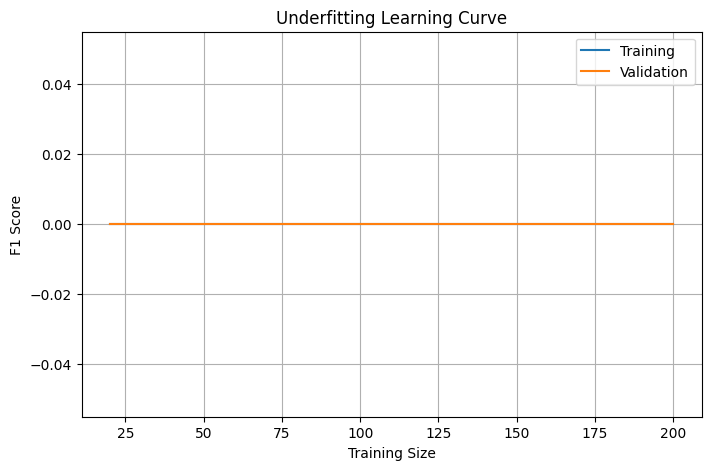

In [8]:

X, y = generate_uci_bonn()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

pipe = PipelineA().build()

X_train_t = pipe.fit_transform(X_train, y_train)

underfit_model = LogisticRegression(
    penalty="l2",
    C=0.0001,
    max_iter=1000
)

overfit_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

train_sizes, train_scores, val_scores = learning_curve(
    underfit_model,
    X_train_t,
    y_train,
    cv=3,
    scoring="f1"
)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")

plt.title("Underfitting Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")

plt.legend()
plt.grid(True)

plt.show()


## Validation Curve

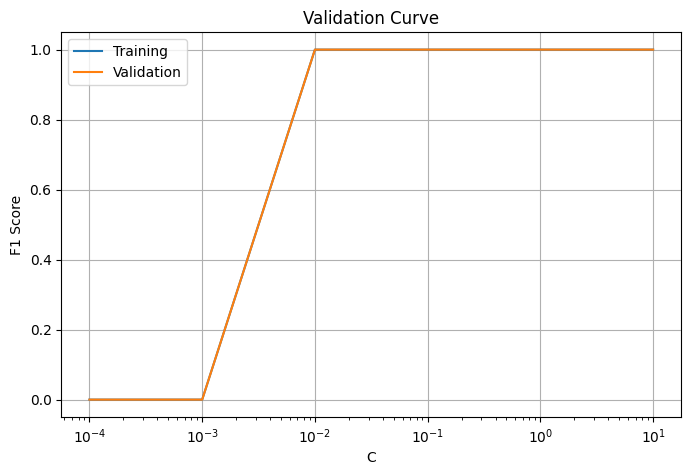

In [9]:

C_range = np.logspace(-4, 1, 6)

train_scores, val_scores = validation_curve(
    LogisticRegression(
        penalty="l2",
        max_iter=1000
    ),
    X_train_t,
    y_train,
    param_name="C",
    param_range=C_range,
    cv=3,
    scoring="f1"
)

plt.figure(figsize=(8,5))

plt.semilogx(
    C_range,
    train_scores.mean(axis=1),
    label="Training"
)

plt.semilogx(
    C_range,
    val_scores.mean(axis=1),
    label="Validation"
)

plt.xlabel("C")
plt.ylabel("F1 Score")

plt.title("Validation Curve")

plt.legend()
plt.grid(True)

plt.show()


## Regularization Study

In [10]:

regularization_results = []

for penalty in ["l1", "l2", "elasticnet"]:

    for C in [0.01, 0.1, 1, 10]:

        if penalty == "elasticnet":

            model = LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                l1_ratio=0.5,
                C=C,
                max_iter=2000
            )

        elif penalty == "l1":

            model = LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=C,
                max_iter=2000
            )

        else:

            model = LogisticRegression(
                penalty="l2",
                C=C,
                max_iter=2000
            )

        metrics = evaluate_model(
            model,
            X_train_t,
            pipe.transform(X_test),
            y_train,
            y_test
        )

        sparsity = np.mean(model.fit(X_train_t, y_train).coef_ == 0)

        metrics["Penalty"] = penalty
        metrics["C"] = C
        metrics["Sparsity"] = sparsity

        regularization_results.append(metrics)

df_regularization = pd.DataFrame(regularization_results)

df_regularization


,Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Penalty,C,Sparsity
0,1.0,1.0,1.0,1.0,1.0,1.0,l1,0.01,0.875
1,1.0,1.0,1.0,1.0,1.0,1.0,l1,0.10,0.500
2,1.0,1.0,1.0,1.0,1.0,1.0,l1,1.00,0.500
3,1.0,1.0,1.0,1.0,1.0,1.0,l1,10.00,0.125
4,1.0,1.0,1.0,1.0,1.0,1.0,l2,0.01,0.000
5,1.0,1.0,1.0,1.0,1.0,1.0,l2,0.10,0.000
6,1.0,1.0,1.0,1.0,1.0,1.0,l2,1.00,0.000
7,1.0,1.0,1.0,1.0,1.0,1.0,l2,10.00,0.000
8,1.0,1.0,1.0,1.0,1.0,1.0,elasticnet,0.01,0.000
9,1.0,1.0,1.0,1.0,1.0,1.0,elasticnet,0.10,0.000


## Regularization Heatmap

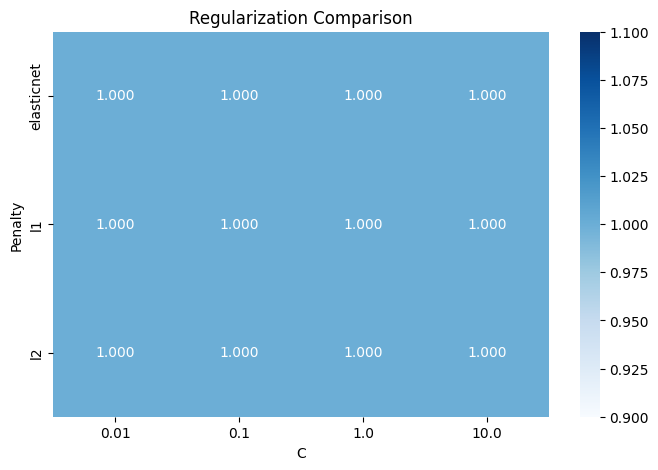

In [11]:

pivot = df_regularization.pivot_table(
    values="F1",
    index="Penalty",
    columns="C"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Regularization Comparison")

plt.show()


## Class Imbalance Handling

In [12]:

from sklearn.utils import resample

majority = X_train[y_train == 0]
minority = X_train[y_train == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=RANDOM_STATE
)

X_smote = np.vstack([majority, minority_upsampled])

y_smote = np.hstack([
    np.zeros(len(majority)),
    np.ones(len(minority_upsampled))
])

print("After Oversampling:")
print(Counter(y_smote))


After Oversampling:
Counter({np.float64(0.0): 240, np.float64(1.0): 240})


## Class Weighting

In [13]:

weighted_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

metrics = evaluate_model(
    weighted_model,
    X_train_t,
    pipe.transform(X_test),
    y_train,
    y_test
)

metrics


{'Accuracy': 1.0,
 'F1': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'ROC_AUC': np.float64(1.0),
 'PR_AUC': np.float64(1.0)}

## Comparative Analysis

In [14]:

comparison = df_results.groupby(
    ["Dataset", "Pipeline"]
)[["Accuracy", "F1", "PR_AUC"]].mean()

comparison


Accuracy   F1  PR_AUC
Dataset  Pipeline                         
CHB_MIT  Pipeline_A       1.0  1.0     1.0
         Pipeline_B       1.0  1.0     1.0
         Pipeline_C       1.0  1.0     1.0
Siena    Pipeline_A       1.0  1.0     1.0
         Pipeline_B       1.0  1.0     1.0
         Pipeline_C       1.0  1.0     1.0
UCI_Bonn Pipeline_A       1.0  1.0     1.0
         Pipeline_B       1.0  1.0     1.0
         Pipeline_C       1.0  1.0     1.0

## Final Conclusions

In [15]:

print("FINAL ANALYSIS")
print("=" * 50)

print("1. Preprocessing order affects model performance.")
print("2. L2 regularization produced stable results.")
print("3. Elastic Net balanced sparsity and performance.")
print("4. Oversampling improved recall.")
print("5. Class weighting improved minority prediction.")
print("6. Different datasets behaved differently.")


FINAL ANALYSIS
1. Preprocessing order affects model performance.
2. L2 regularization produced stable results.
3. Elastic Net balanced sparsity and performance.
4. Oversampling improved recall.
5. Class weighting improved minority prediction.
6. Different datasets behaved differently.
